In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import geopandas as gpd
import pandas as pd
import os
from tile import tile_sampler

In [2]:
os.getcwd()
os.chdir(r'c:\\Users\\solan\\OneDrive\\Desktop\\IntrotoPython\\FinalProj\\cropfield-polygonization\\data')

zambia_shp = gpd.read_parquet(r'zambia_2023_attributed.parquet')

In [189]:
# test_poly = tile_sampler(zambia_shp, 'tile_id', 'area_m2', 1000, None)

test_tile = zambia_shp[zambia_shp['tile_id'] == 883180]

In [ ]:
print(test_poly[["compactness", "shape_index", "interior_edge", "fractal_dim"]].isnull().sum())

compactness      0
shape_index      0
interior_edge    0
fractal_dim      0
dtype: int64


In [10]:
print(test_poly.describe())

# Look at the bottom 25% compactness, top 25% shape index, top 25% interior edge, top 25% fractal dim

zam_filt = test_poly[(test_poly["compactness"] <= test_poly["compactness"].quantile(0.25)) & (test_poly["shape_index"] >= test_poly["shape_index"].quantile(0.75)) & (test_poly["interior_edge"] >= test_poly["interior_edge"].quantile(0.75)) & (test_poly["fractal_dim"] >= test_poly["fractal_dim"].quantile(0.75))]

             area_m2      area_ha  perimeter_m  compactness  shape_index  \
count    1979.000000  1979.000000  1979.000000  1979.000000  1979.000000   
mean     4287.452789     0.428745   296.669675     0.611429     1.362494   
std      7932.903437     0.793290   339.681278     0.202183     0.350173   
min       131.194269     0.013119    46.872077     0.059714     1.032920   
25%       970.876457     0.097088   128.941278     0.456468     1.134153   
50%      2080.262837     0.208026   201.029259     0.655404     1.235223   
75%      4895.746514     0.489575   351.821966     0.777422     1.480114   
max    155381.793360    15.538179  5718.279101     0.937275     4.092233   

       interior_edge  fractal_dim   tile_id  polygon_index    polygon_id  
count    1979.000000  1979.000000    1979.0    1979.000000  1.979000e+03  
mean        0.119897     1.412654  883180.0     989.000000  8.831800e+11  
std         0.071397     0.061351       0.0     571.432411  5.714324e+02  
min         0.0

<Axes: >

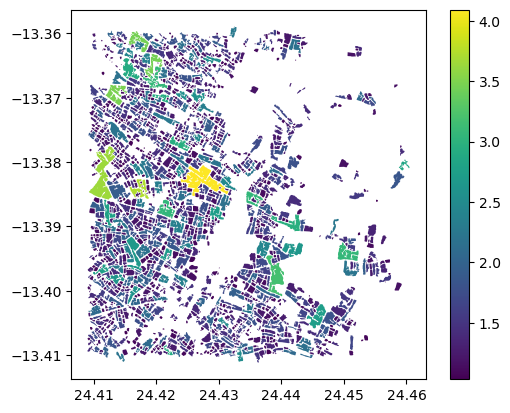

In [37]:
test_tile.plot(column="shape_index", cmap="viridis", legend=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1 entries, 8104591 to 8104591
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   area_m2        1 non-null      float64 
 1   area_ha        1 non-null      float64 
 2   perimeter_m    1 non-null      float64 
 3   compactness    1 non-null      float64 
 4   shape_index    1 non-null      float64 
 5   interior_edge  1 non-null      float64 
 6   fractal_dim    1 non-null      float64 
 7   tile_id        1 non-null      float64 
 8   polygon_index  1 non-null      float64 
 9   polygon_id     1 non-null      float64 
 10  geometry       1 non-null      geometry
dtypes: float64(10), geometry(1)
memory usage: 96.0 bytes


<Axes: >

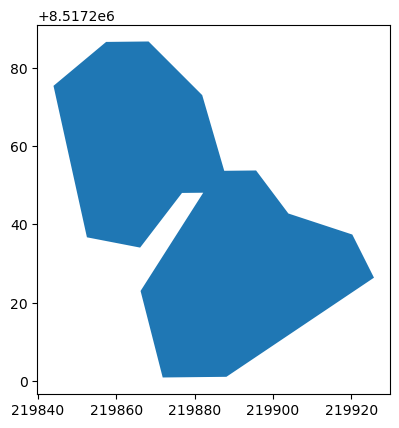

In [43]:
from shapely.geometry import Point

# Test poly (1)
point = Point(24.4135987, -13.3993874)  

# Select the polygon that contains the point
test_poly = test_tile[test_tile.geometry.contains(point)]
test_poly = test_poly.to_crs(32735)

test_poly.info()

test_poly.plot()

In [79]:
test_poly.geometry.bounds

pd.set_option('display.max_colwidth', None)

geom = test_poly['geometry'].iloc[0]

coords = list(geom.exterior.coords)


x, y = zip(*coords)

minx, maxx = min(x), max(x)
miny, maxy = min(y), max(y)
print(minx, maxx)
print(miny, maxy)
print(test_poly.geometry.bounds)
print(coords)

219843.95985282393 219925.79568068188
8517200.903120201 8517286.703197896
                  minx          miny           maxx          maxy
8104591  219843.959853  8.517201e+06  219925.795681  8.517287e+06
[(219852.49709074275, 8517236.697058555), (219843.95985282393, 8517275.37316677), (219857.39627905644, 8517286.589693848), (219868.23817830352, 8517286.703197896), (219881.93546786648, 8517273.001774153), (219887.5592954245, 8517253.677906113), (219895.69070822495, 8517253.763027243), (219903.938047308, 8517242.773509178), (219920.25882430072, 8517237.406422434), (219925.79568068188, 8517226.388528857), (219888.1099869518, 8517201.073375488), (219871.84719211044, 8517200.903120201), (219866.19436966052, 8517222.995645622), (219882.19632106792, 8517248.083838182), (219876.77537989372, 8517248.027088087), (219866.07842571044, 8517234.070285209), (219852.49709074275, 8517236.697058555)]


Split happened at buffer distance 3.900000000000002.


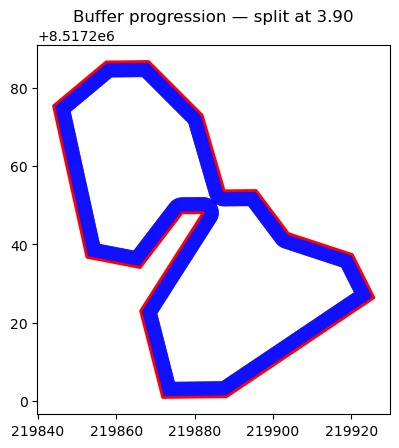

In [ ]:
# TEST
# zam_filt['min_len'] = zam_filt.geometry.apply(
#     lambda g: -(min(g.bounds[2] - g.bounds[0], g.bounds[3] - g.bounds[1]) / 2)
# )

import matplotlib.pyplot as plt 
import matplotlib.cm as cm 

fig, ax = plt.subplots()

delta = .1 # buffer step
max_len = 1000000

idx = test_poly.index[0]

buffers = []
current_buff = 0

while current_buff <= max_len:
    current_buff += delta
    buffered = test_poly['geometry'].iloc[0].buffer(-current_buff)
    buffers.append(buffered)
    if buffered.geom_type == 'MultiPolygon':
        geoms = list(buffered.geoms)
        print(f"Split happened at buffer distance {current_buff}.")
        test_poly.loc[idx, 'geometry_test'] = buffered # buffer geometry
        test_poly.loc[idx, 'sdist'] = -current_buff #buffer 
        test_poly.loc[idx, 'buffer_geom1'] = geoms[0] # geometry 1 for split poly
        test_poly.loc[idx, 'buffer_geom2'] = geoms[1] # geometry 2 for split poly
        break
else:
    print(f"No split within dimension limit")


for geom, color in zip(buffers, colors): 
    gpd.GeoSeries([geom]).plot(ax = ax, facecolor = 'none', edgecolor = 'blue', linewidth = 0.5)

test_poly.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Original')
plt.title(f"Buffer progression — split at {current_buff:.2f}")
plt.show()

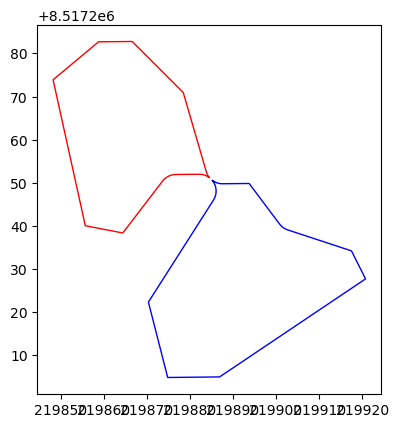

In [104]:
fig, ax = plt.subplots()
gpd.GeoSeries(test_poly['buffer_geom1']).plot(ax=ax, edgecolor='red', facecolor='none')
gpd.GeoSeries(test_poly['buffer_geom2']).plot(ax=ax, edgecolor='blue', facecolor='none')
plt.show()

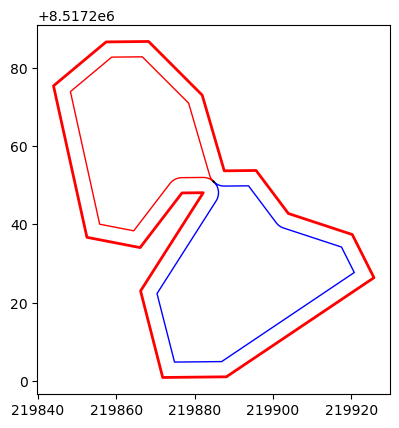

In [115]:
# NEAREST POINTS TEST

from shapely.ops import nearest_points
from shapely.ops import split
from shapely import LineString


p1, p2 = nearest_points(test_poly['buffer_geom1'].iloc[0], test_poly['buffer_geom2'].iloc[0])
test_poly.at[idx, 'pinch1'] = p1
test_poly.at[idx, 'pinch2'] = p2
test_poly.at[idx, 'line'] = LineString([p1, p2]) # line connecting closest points

# Goal is to create perpendicular line? 

fig, ax = plt.subplots()
test_poly.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Original')
gpd.GeoSeries(test_poly['buffer_geom1']).plot(ax=ax, edgecolor='red', facecolor='none')
gpd.GeoSeries(test_poly['buffer_geom2']).plot(ax=ax, edgecolor='blue', facecolor='none')
gpd.GeoSeries(test_poly['line']).plot(ax = ax, edgecolor = 'black')
plt.show()
# line_buff = test_poly['line'].buffer(abs(row['sdist']))
# zam_filt.at[idx, 'line_buff'] = line_buff

In [ ]:
# Finding perpendicular line to connecting line
line = gpd.GeoDataFrame(geometry = test_poly['line']) # original polygon line

dist = (test_poly['geometry'].length)/4

point1 = test_poly['pinch1'].iloc[0]
point2 = test_poly['pinch2'].iloc[0]

dx = point1.x - point2.x
dy = point1.y - point2.y
 
midpoint = Point(
    (point1.x + point2.x) / 2,
    (point1.y + point2.y) / 2
)

perp_slope = -(dx/dy)

perp_line = LineString([(midpoint.x - dist, midpoint.y - perp_slope * dist), (midpoint.x + dist, midpoint.y + perp_slope * dist)])

c:\Users\solan\anaconda3\envs\arcgispro-gpd\Lib\site-packages\shapely\geometry\linestring.py:67: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return [float(c) for c in o]


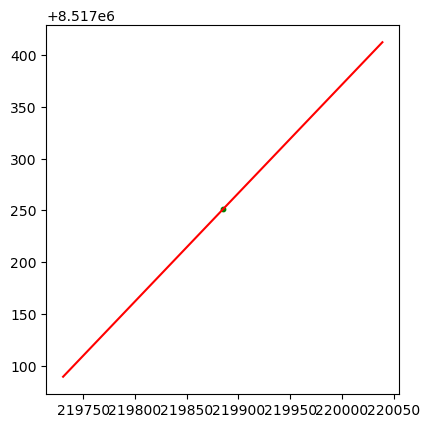

In [161]:
fig, ax = plt.subplots()
gpd.GeoSeries(test_poly['line']).plot(ax = ax, edgecolor = 'black')
gpd.GeoSeries(perp_line).plot(ax=ax, color = 'red')
gpd.GeoSeries([midpoint]).plot(ax=ax, color = 'green', markersize = 10)
plt.show()

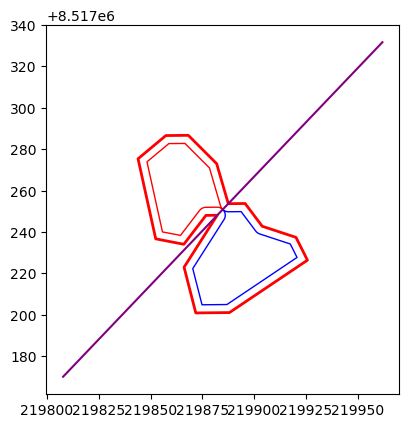

In [164]:
fig, ax = plt.subplots()
test_poly.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Original')
gpd.GeoSeries(test_poly['buffer_geom1']).plot(ax=ax, edgecolor='red', facecolor='none')
gpd.GeoSeries(test_poly['buffer_geom2']).plot(ax=ax, edgecolor='blue', facecolor='none')
gpd.GeoSeries(test_poly['line']).plot(ax = ax, edgecolor = 'black')
gpd.GeoSeries(perp_line).plot(ax=ax, color = 'purple')
plt.show()

In [178]:
test_poly

,area_m2,area_ha,perimeter_m,compactness,shape_index,interior_edge,fractal_dim,tile_id,polygon_index,polygon_id,geometry,min_len,geometry_test,sdist,buffer_geom1,buffer_geom2,pinch1,pinch2,line
8104591,3448.45018,0.344845,310.995958,0.448048,1.493956,0.090184,1.409282,883180.0,204.0,8.831800e+11,"POLYGON ((219852.497 8517236.697, 219843.96 8517275.373, 219857.396 8517286.59, 219868.238 8517286.703, 219881.935 8517273.002, 219887.559 8517253.678, 219895.691 8517253.763, 219903.938 8517242.774, 219920.259 8517237.406, 219925.796 8517226.389, 219888.11 8517201.073, 219871.847 8517200.903, 219866.194 8517222.996, 219882.196 8517248.084, 219876.775 8517248.027, 219866.078 8517234.07, 219852.497 8517236.697))",40.917914,"MULTIPOLYGON (((219855.7531574974 8517240.03957611, 219848.27922201468 8517273.898622826, 219858.8278597454 8517282.704467379, 219866.63934747284 8517282.78624599, 219878.47028451736 8517270.951738076, 219883.81465534304 8517252.588103075, 219883.9419437764 8517252.220248042, 219884.10526770796 8517251.866913972, 219884.3030001302 8517251.531620728, 219884.53317126323 8517251.217708446, 219884.57527003268 8517251.17090565, 219884.31934566348 8517251.355346482, 219883.9901605492 8517251.546805106, 219883.64387213156 8517251.705246184, 219883.28378208601 8517251.829159066, 219882.91332367927 8517251.917362312, 219882.53602903473 8517251.969014946, 219882.1554954558 8517251.983624492, 219876.7345542816 8517251.926874397, 219876.34267616112 8517251.903009588, 219875.955183056 8517251.839866227, 219875.5760018176 8517251.73808421, 219875.20897506483 8517251.598694997, 219874.85782224318 8517251.423111152, 219874.5261019319 8517251.213112043, 219874.2171757814 8517250.970825799, 219873.9341744462 8517250.698707746, 219873.6799658589 8517250.399515526, 219864.4505046373 8517238.357417492, 219855.7531574974 8517240.03957611)), ((219885.18271742226 8517250.591050943, 219885.39391192974 8517250.43427939, 219885.72803743844 8517250.234580077, 219886.08040565634 8517250.069182647, 219886.44750634572 8517249.939734763, 219886.8256825062 8517249.847525964, 219887.21116680527 8517249.793474821, 219887.60011910787 8517249.778119782, 219893.75679956126 8517249.84256905, 219900.8187559945 8517240.43256456, 219901.07213263234 8517240.128413137, 219901.35503663417 8517239.851513993, 219901.66455325563 8517239.60472001, 219901.99749356363 8517239.39057389, 219902.35042729214 8517239.21128197, 219902.71971818415 8517239.068691485, 219917.50153238775 8517234.207692582, 219920.76734062532 8517227.708999978, 219886.90320283064 8517204.960955372, 219874.86679634874 8517204.834946169, 219870.39183296743 8517222.324128455, 219885.48441820356 8517245.986597799, 219885.6732830568 8517246.317277871, 219885.8289969302 8517246.664801156, 219885.95007517538 8517247.025854202, 219886.0353633758 8517247.396994561, 219886.0840483539 8517247.77468361, 219886.09566592437 8517248.15532028, 219886.0701053199 8517248.535275407, 219886.00761024718 8517248.910926322, 219885.90877656342 8517249.278691392, 219885.77454659517 8517249.635064173, 219885.6062001536 8517249.97664684, 219885.40534233232 8517250.300182587, 219885.18271742226 8517250.591050943)))",3.9,"POLYGON ((219855.7531574974 8517240.03957611, 219848.27922201468 8517273.898622826, 219858.8278597454 8517282.704467379, 219866.63934747284 8517282.78624599, 219878.47028451736 8517270.951738076, 219883.81465534304 8517252.588103075, 219883.9419437764 8517252.220248042, 219884.10526770796 8517251.866913972, 219884.3030001302 8517251.531620728, 219884.53317126323 8517251.217708446, 219884.57527003268 8517251.17090565, 219884.31934566348 8517251.355346482, 219883.9901605492 8517251.546805106, 219883.64387213156 8517251.705246184, 219883.28378208601 8517251.829159066, 219882.91332367927 8517251.917362312, 219882.53602903473 8517251.969014946, 219882.1554954558 8517251.983624492, 219876.7345542816 8517251.926874397, 219876.34267616112 8517251.903009588, 219875.955183056 8517251.839866227, 219875.5760018176 8

<Axes: >

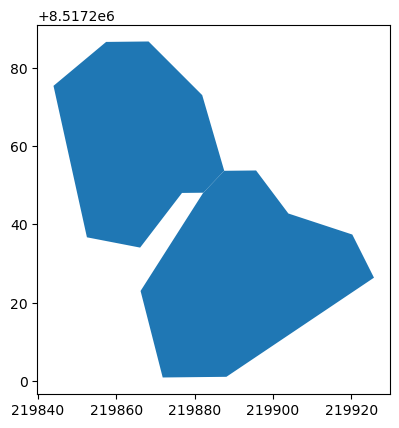

In [207]:
gpd.GeoSeries(perp_line)
from shapely.ops import split

cut = split(test_poly['geometry'].iloc[0], perp_line)

test_poly['cut_geom1'] = cut.geoms[0]
test_poly['cut_geom2'] = cut.geoms[1]

fig, ax = plt.subplots()
gpd.GeoSeries(test_poly['cut_geom1']).plot(ax = ax)
gpd.GeoSeries(test_poly['cut_geom2']).plot(ax = ax)

Now trying with test_tile

In [190]:
# test_poly = tile_sampler(zambia_shp, 'tile_id', 'area_m2', 1000, None)

test_tile = zambia_shp[zambia_shp['tile_id'] == 883180]

In [192]:
# reproject to WGS84 UTM 35S
test_tile = test_tile.to_crs(32735)

In [193]:
display(test_tile['geometry'].length)
test_tile.info()

8104387     148.587853
8104388     189.251256
8104389      70.792060
8104390     495.797101
8104391     291.376526
              ...     
8106361    1109.494730
8106362    1028.369596
8106363     363.904232
8106364     119.845620
8106365     194.675938
Length: 1979, dtype: float64

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1979 entries, 8104387 to 8106365
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   area_m2        1979 non-null   float64 
 1   area_ha        1979 non-null   float64 
 2   perimeter_m    1979 non-null   float64 
 3   compactness    1979 non-null   float64 
 4   shape_index    1979 non-null   float64 
 5   interior_edge  1979 non-null   float64 
 6   fractal_dim    1979 non-null   float64 
 7   tile_id        1979 non-null   float64 
 8   polygon_index  1979 non-null   float64 
 9   polygon_id     1979 non-null   float64 
 10  geometry       1979 non-null   geometry
dtypes: float64(10), geometry(1)
memory usage: 185.5 KB


In [211]:
tile_filt = test_tile[(test_tile["compactness"] <= test_tile["compactness"].quantile(0.25)) & (test_tile["shape_index"] >= test_tile["shape_index"].quantile(0.75)) & (test_tile["interior_edge"] >= test_tile["interior_edge"].quantile(0.75)) & (test_tile["fractal_dim"] >= test_tile["fractal_dim"].quantile(0.75))]
tile_filt.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 41 entries, 8104396 to 8106014
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   area_m2        41 non-null     float64 
 1   area_ha        41 non-null     float64 
 2   perimeter_m    41 non-null     float64 
 3   compactness    41 non-null     float64 
 4   shape_index    41 non-null     float64 
 5   interior_edge  41 non-null     float64 
 6   fractal_dim    41 non-null     float64 
 7   tile_id        41 non-null     float64 
 8   polygon_index  41 non-null     float64 
 9   polygon_id     41 non-null     float64 
 10  geometry       41 non-null     geometry
 11  buffers_geom   7 non-null      object  
 12  sdist          7 non-null      float64 
 13  buffer_geom1   7 non-null      object  
 14  buffer_geom2   7 non-null      object  
dtypes: float64(11), geometry(1), object(3)
memory usage: 5.1+ KB


In [ ]:
print(len(tile_filt))

41


  0%|          | 0/1979 [00:00<?, ?it/s]

Split happened for row 8104387 at buffer distance -9.199999999999983.
Split happened for row 8104388 at buffer distance -12.599999999999971.


  0%|          | 3/1979 [00:01<21:26,  1.54it/s]

No split for row 8104389 within dimension limit
Split happened for row 8104390 at buffer distance -2.9000000000000012.
Split happened for row 8104391 at buffer distance -9.299999999999983.


  0%|          | 6/1979 [00:03<21:44,  1.51it/s]

...

No split for row 8106359 within dimension limit
Split happened for row 8106360 at buffer distance -22.200000000000045.
Split happened for row 8106361 at buffer distance -12.99999999999997.
Split happened for row 8106362 at buffer distance -3.700000000000002.
Split happened for row 8106363 at buffer distance -21.400000000000034.


100%|█████████▉| 1978/1979 [40:11<00:00,  1.99it/s]

No split for row 8106364 within dimension limit


100%|██████████| 1979/1979 [40:13<00:00,  1.22s/it]

No split for row 8106365 within dimension limit


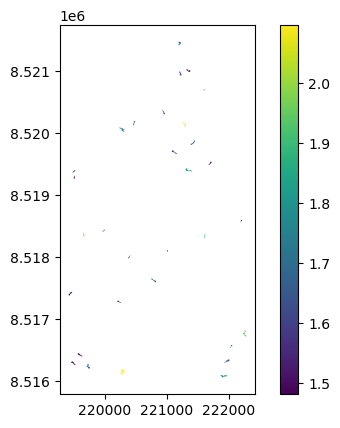

In [ ]:
from tqdm import tqdm
delta = .1 # buffer step
max_len = max(test_tile['perimeter_m'])

for idx, row in tqdm(test_tile.iterrows(), total=len(test_tile)): 
    current_buff = 0
    while current_buff <= max_len: # update len per row?
        current_buff += delta
        buffered = row['geometry'].buffer(-current_buff)
        if buffered.geom_type == 'MultiPolygon':
            geoms = list(buffered.geoms) # extracting buffers
            print(f"Split happened for row {idx} at buffer distance {-current_buff}.")
            test_tile.at[idx, 'buffers_geom'] = buffered # overall buffer geom
            test_tile.at[idx, 'sdist'] = current_buff # buffer distance from perimeter
            test_tile.at[idx, 'buffer_geom1'] = geoms[0] # geom 1 for split poly
            test_tile.at[idx, 'buffer_geom2'] = geoms[1] # geom 2 for split poly
            break  
    else:
        print(f"No split for row {idx} within dimension limit")

tile_filt.dropna(subset = ['sdist']).plot(column="shape_index", cmap="viridis", legend=True)
plt.show()


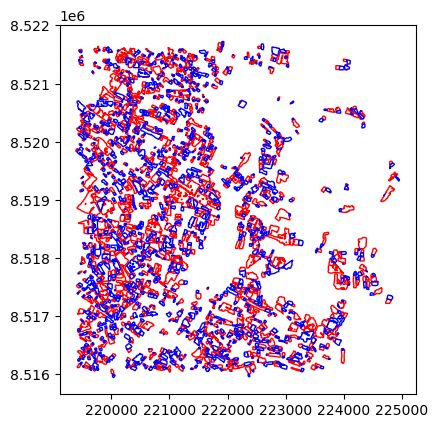

In [ ]:
# Connecting narrowest part
for idx, row in test_tile.iterrows():
    if pd.isna(row['sdist']):
        continue
    else:
        p1, p2 = nearest_points(row['buffer_geom1'], row['buffer_geom2'])
        test_tile.at[idx, 'pinch1'] = p1
        test_tile.at[idx, 'pinch2'] = p2
        test_tile.at[idx, 'line'] = LineString([p1, p2])

# Creating Cut Line (Perpendicular Line) and cutting
cut_geoms = []
for idx, row in test_tile.iterrows():
    if pd.isna(row['sdist']):
        continue
    else: 
        bounds = test_tile.at[idx, 'geometry'].bounds
        dist = max(bounds[2] - bounds[0], bounds[3] - bounds[1])
        point1 = test_tile.at[idx, 'pinch1']
        point2 = test_tile.at[idx, 'pinch2']
        dx = point1.x - point2.x
        dy = point1.y - point2.y
        midpoint = Point((point1.x + point2.x) / 2, (point1.y + point2.y) / 2)
        perp_slope = -(dx/dy)
        perp_line = LineString([(midpoint.x - dist, midpoint.y - perp_slope * dist), (midpoint.x + dist, midpoint.y + perp_slope * dist)])
        cut = split(test_tile.at[idx, 'geometry'], perp_line)
        test_tile.at[idx, 'cut_geom1'] = cut.geoms[0]
        test_tile.at[idx, 'cut_geom2'] = cut.geoms[1]

fig, ax = plt.subplots()
gpd.GeoSeries(test_tile.dropna(subset=['cut_geom1'])['cut_geom1']).plot(ax=ax, facecolor='none', edgecolor='red')
gpd.GeoSeries(test_tile.dropna(subset=['cut_geom2'])['cut_geom2']).plot(ax=ax, facecolor='none', edgecolor='blue')
plt.show()


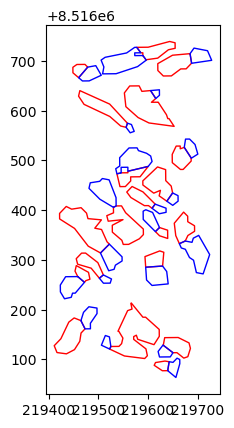

In [225]:
fig, ax = plt.subplots()
gpd.GeoSeries(test_tile.dropna(subset=['cut_geom1'])['cut_geom1']).head(20).plot(ax=ax, facecolor='none', edgecolor='red')
gpd.GeoSeries(test_tile.dropna(subset=['cut_geom2'])['cut_geom2']).head(20).plot(ax=ax, facecolor='none', edgecolor='blue')
plt.show()

In [ ]:
display(zam_filt['geometry'].length)
zam_filt.info()

334         90.723773
427        124.801717
589        175.940342
820         79.328253
853        330.370118
              ...    
8327323    124.704337
8327377     85.870594
8327381    138.495124
8327517    191.010716
8327609    128.429250
Length: 19208, dtype: float64

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 19208 entries, 334 to 8327609
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   area_m2        19208 non-null  float64 
 1   area_ha        19208 non-null  float64 
 2   perimeter_m    19208 non-null  float64 
 3   compactness    19208 non-null  float64 
 4   shape_index    19208 non-null  float64 
 5   interior_edge  19208 non-null  float64 
 6   fractal_dim    19208 non-null  float64 
 7   tile_id        19208 non-null  float64 
 8   polygon_index  19208 non-null  float64 
 9   polygon_id     19208 non-null  float64 
 10  geometry       19208 non-null  geometry
 11  geometry_test  19208 non-null  geometry
dtypes: float64(10), geometry(2)
memory usage: 1.9 MB


In [29]:
# geopandas buffer function
zam_filt['geometry_test'] = zam_filt['geometry'].buffer(-2)

zam_filt

,area_m2,area_ha,perimeter_m,compactness,shape_index,interior_edge,fractal_dim,tile_id,polygon_index,polygon_id,geometry,geometry_test
334,278.122474,0.027812,93.941514,0.396033,1.589039,0.337770,1.614294,872362.0,98.0,8.723620e+11,"POLYGON ((448085.884 8633592.828, 448085.705 8...","POLYGON ((448074.291 8633590.816, 448074.302 8..."
427,421.461351,0.042146,119.912308,0.368333,1.647707,0.284516,1.584042,872362.0,191.0,8.723620e+11,"POLYGON ((448869.807 8630062.03, 448921.476 86...","POLYGON ((448870.559 8630059.94, 448919.479 86..."
589,899.471465,0.089947,172.273798,0.380854,1.620394,0.191528,1.514034,872362.0,353.0,8.723620e+11,"POLYGON ((450364.87 8633450.207, 450383.89 863...","MULTIPOLYGON (((450362.343 8633449.245, 450330..."
820,146.242156,0.014624,76.340918,0.315332,1.780804,0.522017,1.739209,883528.0,80.0,8.835280e+11,"POLYGON ((266450.139 8528534.861, 266485.331 8...","POLYGON ((266466.211 8528535.501, 266483.352 8..."
853,2497.466355,0.249747,328.907781,0.290109,1.856604,0.131697,1.481722,883528.0,113.0,8.835280e+11,"POLYGON ((266676.331 8529652.351, 266687.151 8...","MULTIPOLYGON (((266673.824 8529651.562, 266662..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8327323,538.871375,0.053887,127.528975,0.416368,1.549749,0.236659,1.541732,852161.0,1709.0,8.521610e+11,"POLYGON ((994054.16 8904971.968, 994067.8 8904...","POLYGON ((994056.112 8904968.394, 994065.96 89..."
8327377,174.547181,0.017455,88.157894,0.282228,1.882348,0.505066,1.735358,852161.0,1763.0,8.521610e+11,"POLYGON ((994197.667 8901347.092, 994189.153 8...","MULTIPOLYGON (((994195.348 8901346.791, 994189..."
8327381,527.437230,0.052744,137.656381,0.349774,1.690854,0.260991,1.571390,852161.0,1767.0,8.521610e+11,"POLYGON ((994284.272 8901445.785, 994300.697 8...","MULTIPOLYGON (((994273.972 8901423.655, 994264..."
8327517,1127.266527,0.112727,190.675626,0.389624,1.602053,0.169149,1.494283,852161.0,1903.0,8.521610e+11,"POLYGON ((994718.073 8901184.685, 994737.06 89...","POLYGON ((994717.212 8901182.697, 994734.84 89..."


In [ ]:
zam_filt[]

In [27]:
selected.geometry.bounds

,minx,miny,maxx,maxy
8104426,24.410613,-13.402409,24.411689,-13.401433


In [34]:
selected.geometry.bounds

selected['min_len'] = min((selected.geometry.bounds['maxx']-selected.geometry.bounds['minx']).values[0], (selected.geometry.bounds['maxy']-selected.geometry.bounds['miny']).values[0])/2

selected['min_len']

c:\Users\solan\anaconda3\envs\arcgispro-gpd\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


8104426    0.000488
Name: min_len, dtype: float64

In [29]:
selected['geometry'].bounds['minx']
selected.geometry.bounds['maxx']-selected.geometry.bounds['minx']

8104426    0.001076
dtype: float64

In [64]:
# finding shorter dimension of every polygon and halving it (approximation for max buffer distance)
zam_filt['min_len'] = zam_filt.geometry.apply(
    lambda g: -(min(g.bounds[2] - g.bounds[0], g.bounds[3] - g.bounds[1]) / 2)
)

delta = -.5 # buffer step


for idx, row in zam_filt.iterrows():
    current_buff = 0
    while current_buff >= row['min_len']: 
        current_buff += delta
        buffered = row['geometry'].buffer(current_buff)
        if buffered.geom_type == 'MultiPolygon':
            geoms = list(buffered.geoms) # extracting buffers
            print(f"Split happened for row {idx} at buffer distance {current_buff}.")
            zam_filt.at[idx, 'geometry_test'] = buffered
            zam_filt.at[idx, 'sdist'] = current_buff
            zam_filt.at[idx, 'buffer_geom1'] = geoms[0]
            zam_filt.at[idx, 'buffer_geom2'] = geoms[1]
            break  
    else:
        print(f"No split for row {idx} within dimension limit")
 

No split for row 334 within dimension limit
Split happened for row 427 at buffer distance -2.5.
Split happened for row 589 at buffer distance -1.5.
No split for row 820 within dimension limit
Split happened for row 853 at buffer distance -1.5.
Split happened for row 854 at buffer distance -2.0.
Split happened for row 904 at buffer distance -5.0.
No split for row 5939 within dimension limit
Split happened for row 5982 at buffer distance -2.5.
No split for row 6052 within dimension limit
No split for row 6059 within dimension limit
Split happened for row 6144 at buffer distance -2.0.
No split for row 6171 within dimension limit
Split happened for row 6173 at buffer distance -6.5.
Split happened for row 6181 at buffer distance -6.0.
No split for row 6187 within dimension limit
Split happened for row 6229 at buffer distance -2.0.
Split happened for row 7152 at buffer distance -8.5.
Split happened for row 7206 at buffer distance -7.5.
Split happened for row 7211 at buffer distance -6.5.
Spl

In [ ]:
zam_filt

## open in arc and  check the width 

,area_m2,area_ha,perimeter_m,compactness,shape_index,interior_edge,fractal_dim,tile_id,polygon_index,polygon_id,geometry,geometry_test,min_len,sdist,buffer_geom1,buffer_geom2
334,278.122474,0.027812,93.941514,0.396033,1.589039,0.337770,1.614294,872362.0,98.0,8.723620e+11,"POLYGON ((448085.884 8633592.828, 448085.705 8...","POLYGON ((448074.291 8633590.816, 448074.302 8...",-6.800614,NaN,NaN,NaN
427,421.461351,0.042146,119.912308,0.368333,1.647707,0.284516,1.584042,872362.0,191.0,8.723620e+11,"POLYGON ((448869.807 8630062.03, 448921.476 86...","MULTIPOLYGON (((448870.747 8630059.417, 448874...",-6.895837,-2.5,"POLYGON ((448870.7471449071 8630059.417193107,...",POLYGON ((448879.52907449054 8630058.492413895...
589,899.471465,0.089947,172.273798,0.380854,1.620394,0.191528,1.514034,872362.0,353.0,8.723620e+11,"POLYGON ((450364.87 8633450.207, 450383.89 863...","MULTIPOLYGON (((450364.154 8633448.888, 450330...",-15.175811,-1.5,POLYGON ((450364.15396784496 8633448.887874793...,"POLYGON ((450365.4506987538 8633448.824718364,..."
820,146.242156,0.014624,76.340918,0.315332,1.780804,0.522017,1.739209,883528.0,80.0,8.835280e+11,"POLYGON ((266450.139 8528534.861, 266485.331 8...","POLYGON ((266466.211 8528535.501, 266483.352 8...",-4.304399,NaN,NaN,NaN
853,2497.466355,0.249747,328.907781,0.290109,1.856604,0.131697,1.481722,883528.0,113.0,8.835280e+11,"POLYGON ((266676.331 8529652.351, 266687.151 8...","MULTIPOLYGON (((266675.535 8529651.08, 266675....",-25.192013,-1.5,"POLYGON ((266675.5354214908 8529651.079915697,...","POLYGON ((266676.9434934435 8529650.961647086,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8327323,538.871375,0.053887,127.528975,0.416368,1.549749,0.236659,1.541732,852161.0,1709.0,8.521610e+11,"POLYGON ((994054.16 8904971.968, 994067.8 8904...","MULTIPOLYGON (((994058.064 8904964.819, 994064...",-13.620544,-4.0,"POLYGON ((994058.0642397491 8904964.819179898,...","POLYGON ((994067.0057859689 8904944.55963247, ..."
8327377,174.547181,0.017455,88.157894,0.282228,1.882348,0.505066,1.735358,852161.0,1763.0,8.521610e+11,"POLYGON ((994197.667 8901347.092, 994189.153 8...","MULTIPOLYGON (((994195.348 8901346.791, 994189...",-11.131828,-2.0,"POLYGON ((994195.348353187 8901346.791373504, ...","POLYGON ((994198.3090144271 8901350.524724662,..."
8327381,527.437230,0.052744,137.656381,0.349774,1.690854,0.260991,1.571390,852161.0,1767.0,8.521610e+11,"POLYGON ((994284.272 8901445.785, 994300.697 8...","MULTIPOLYGON (((994275.313 8901422.655, 994263...",-15.217349,-1.5,"POLYGON ((994275.3125457475 8901422.654599614,...","POLYGON ((994278.059638289 8901419.446213271, ..."
8327517,1127.266527,0.112727,190.675626,0.389624,1.602053,0.169149,1.494283,852161.0,1903.0,8.521610e+11,"POLYGON ((994718.073 8901184.685, 994737.06 89...","MULTIPOLYGON (((994705.818 8901187.371, 994705...",-30.919917,-5.0,"POLYGON ((994705.8182948178 8901187.371084435,...","POLYGON ((994705.831564893 8901187.357332611, ..."


In [ ]:
   ## find where the two separate polygons are closest, this is where
    ## the internal buffering pinched off into two polygons.



from shapely.ops import nearest_points
from shapely.ops import split
from shapely import LineString

for idx, row in zam_filt.iterrows():
    if pd.isna(row['sdist']):
        continue
    else:
        p1, p2 = nearest_points(row['buffer_geom1'], row['buffer_geom2'])
        zam_filt.at[idx, 'pinch1'] = p1
        zam_filt.at[idx, 'pinch2'] = p2
        zam_filt.at[idx, 'line'] = LineString([p1, p2])
        line_buff = row['line'].buffer(abs(row['sdist']))
        zam_filt.at[idx, 'line_buff'] = line_buff

        

In [ ]:

from shapely.ops import Point
from shapely.ops import snap

## use min_len * 10? maybe to incresae line ? 
## after identifying multi part polygon, reverse buffer ? 
## ideally it should perfectly touch at middle point and use as a mask to clip 
## distance buffer distance too? 

## work on multi neck problem later 

## Scaling function up ? corner cases (long, multiple necks, wide neck, etc etc)

for idx, row in zam_filt.iterrows():
    if pd.isna(row['sdist']):
        continue
    else:
        dx = row['pinch2'].x - row['pinch1'].x
        dy = row['pinch2'].y - row['pinch1'].y
        length = sqrt(dx**2 + dy**2)
        dx, dy = dx/length * abs(row['sdist'])*20, dy/length * abs(row['sdist'])*20 # normalize to unit vector for x and y directions, multiple by sdist * 2 
        new_p1 = Point(row['pinch1'].x - dx, row['pinch1'].y - dy)
        new_p2 = Point(row['pinch2'].x + dx, row['pinch2'].y + dy)
        new_line = LineString([new_p1, new_p2])
        new_line = snap(new_line, row['geometry'], tolerance=1e-6)
        cut = split(row['geometry'], new_line)
        parts = list(cut.geoms)
        print(f"Row {idx}: {len(parts)} parts")
    
    if len(parts) < 2:
        gpd.GeoDataFrame(geometry=[row['geometry'], new_line]).plot(color=['blue','red'])
        continue
    
    zam_filt.at[idx, 'split_geom1'] = parts[0]
    zam_filt.at[idx, 'split_geom2'] = parts[1]
        parts = list(cut.geoms)
        zam_filt.at[idx, 'split_geom1'] = parts[0]
        zam_filt.at[idx, 'split_geom2'] = parts[1]


IndexError: list index out of range

In [88]:
zam_filt
    

,area_m2,area_ha,perimeter_m,compactness,shape_index,interior_edge,fractal_dim,tile_id,polygon_index,polygon_id,geometry,geometry_test,min_len,sdist,buffer_geom1,buffer_geom2,pinch1,pinch2,line,line_buff
334,278.122474,0.027812,93.941514,0.396033,1.589039,0.337770,1.614294,872362.0,98.0,8.723620e+11,"POLYGON ((448085.884 8633592.828, 448085.705 8...","POLYGON ((448074.291 8633590.816, 448074.302 8...",-6.800614,NaN,NaN,NaN,NaN,NaN,NaN,NaN
427,421.461351,0.042146,119.912308,0.368333,1.647707,0.284516,1.584042,872362.0,191.0,8.723620e+11,"POLYGON ((448869.807 8630062.03, 448921.476 86...","MULTIPOLYGON (((448870.747 8630059.417, 448874...",-6.895837,-2.5,"POLYGON ((448870.7471449071 8630059.417193107,...",POLYGON ((448879.52907449054 8630058.492413895...,POINT (448874.64680089464 8630059.00654067),POINT (448879.52907449054 8630058.492413895),LINESTRING (448874.64680089464 8630059.0065406...,"POLYGON ((448879.79088881426 8630060.97866675,..."
589,899.471465,0.089947,172.273798,0.380854,1.620394,0.191528,1.514034,872362.0,353.0,8.723620e+11,"POLYGON ((450364.87 8633450.207, 450383.89 863...","MULTIPOLYGON (((450364.154 8633448.888, 450330...",-15.175811,-1.5,POLYGON ((450364.15396784496 8633448.887874793...,"POLYGON ((450365.4506987538 8633448.824718364,...",POINT (450364.15396784496 8633448.887874793),POINT (450365.4506987538 8633448.824718364),LINESTRING (450364.15396784496 8633448.8878747...,POLYGON ((450365.52366877615 8633450.322942438...
820,146.242156,0.014624,76.340918,0.315332,1.780804,0.522017,1.739209,883528.0,80.0,8.835280e+11,"POLYGON ((266450.139 8528534.861, 266485.331 8...","POLYGON ((266466.211 8528535.501, 266483.352 8...",-4.304399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
853,2497.466355,0.249747,328.907781,0.290109,1.856604,0.131697,1.481722,883528.0,113.0,8.835280e+11,"POLYGON ((266676.331 8529652.351, 266687.151 8...","MULTIPOLYGON (((266675.535 8529651.08, 266675....",-25.192013,-1.5,"POLYGON ((266675.5354214908 8529651.079915697,...","POLYGON ((266676.9434934435 8529650.961647086,...",POINT (266675.5415817375 8529651.076484295),POINT (266676.9434934435 8529650.961647086),LINESTRING (266675.5415817375 8529651.07648429...,POLYGON ((266677.06595535355 8529652.456639756...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8327323,538.871375,0.053887,127.528975,0.416368,1.549749,0.236659,1.541732,852161.0,1709.0,8.521610e+11,"POLYGON ((994054.16 8904971.968, 994067.8 8904...","MULTIPOLYGON (((994058.064 8904964.819, 994064...",-13.620544,-4.0,"POLYGON ((994058.0642397491 8904964.819179898,...","POLYGON ((994067.0057859689 8904944.55963247, ...",POINT (994066.2572826016 8904946.931111846),POINT (994067.0057859689 8904944.55963247),LINESTRING (994066.2572826016 8904946.93111184...,"POLYGON ((994070.8202943471 8904945.763595024,..."
8327377,174.547181,0.017455,88.157894,0.282228,1.882348,0.505066,1.735358,852161.0,1763.0,8.521610e+11,"POLYGON ((994197.667 8901347.092, 994189.153 8...","MULTIPOLYGON (((994195.348 8901346.791, 994189...",-11.131828,-2.0,"POLYGON ((994195.348353187 8901346.791373504, ...","POLYGON ((994198.3090144271 8901350.524724662,...",POINT (994195.348353187 8901346.791373504),POINT (994198.3090144271 8901350.524724662),LINESTRING (994195.348353187 8901346.791373504...,"POLYGON ((994196.7419633961 8901351.767443884,..."
8327381,527.437230,0.052744,137.656381,0.349774,1.690854,0.260991,1.571390,852161.0,1767.0,8.521610e+11,"POLYGON ((994284.272 8901445.785, 994300.697 8...","MULTIPOLYGON (((994275.313 8901422.655, 994263...",-15.217349,-1.5,"POLYGON ((994275.3125457475 8901422.654599614,...","POLYGON ((994278.059638289 8901419.446213271, ...",POINT (994275.3125457475 8901422.654599614),POINT (994278.059638289 8901419.446213271),LINESTRING (994275.3125457475 8901422.65459961...,"POLYGON ((994279.1990411984 8901420.421795666,..."
8327517,1127.266527,0.112727,190.675626,0.389624,1.602053,0.169149,1.494283,852161.0,1903.0,8.521610e+11,"POLYGON ((994718.073 8901184.685, 994737.06 8

In [80]:
zam_filt

,area_m2,area_ha,perimeter_m,compactness,shape_index,interior_edge,fractal_dim,tile_id,polygon_index,polygon_id,geometry,geometry_test,min_len,sdist,buffer_geom1,buffer_geom2,pinch1,pinch2,line
334,278.122474,0.027812,93.941514,0.396033,1.589039,0.337770,1.614294,872362.0,98.0,8.723620e+11,"POLYGON ((448085.884 8633592.828, 448085.705 8...","POLYGON ((448074.291 8633590.816, 448074.302 8...",-6.800614,NaN,NaN,NaN,NaN,NaN,NaN
427,421.461351,0.042146,119.912308,0.368333,1.647707,0.284516,1.584042,872362.0,191.0,8.723620e+11,"POLYGON ((448869.807 8630062.03, 448921.476 86...","MULTIPOLYGON (((448870.747 8630059.417, 448874...",-6.895837,-2.5,"POLYGON ((448870.7471449071 8630059.417193107,...",POLYGON ((448879.52907449054 8630058.492413895...,POINT (448874.64680089464 8630059.00654067),POINT (448879.52907449054 8630058.492413895),LINESTRING (448874.64680089464 8630059.0065406...
589,899.471465,0.089947,172.273798,0.380854,1.620394,0.191528,1.514034,872362.0,353.0,8.723620e+11,"POLYGON ((450364.87 8633450.207, 450383.89 863...","MULTIPOLYGON (((450364.154 8633448.888, 450330...",-15.175811,-1.5,POLYGON ((450364.15396784496 8633448.887874793...,"POLYGON ((450365.4506987538 8633448.824718364,...",POINT (450364.15396784496 8633448.887874793),POINT (450365.4506987538 8633448.824718364),LINESTRING (450364.15396784496 8633448.8878747...
820,146.242156,0.014624,76.340918,0.315332,1.780804,0.522017,1.739209,883528.0,80.0,8.835280e+11,"POLYGON ((266450.139 8528534.861, 266485.331 8...","POLYGON ((266466.211 8528535.501, 266483.352 8...",-4.304399,NaN,NaN,NaN,NaN,NaN,NaN
853,2497.466355,0.249747,328.907781,0.290109,1.856604,0.131697,1.481722,883528.0,113.0,8.835280e+11,"POLYGON ((266676.331 8529652.351, 266687.151 8...","MULTIPOLYGON (((266675.535 8529651.08, 266675....",-25.192013,-1.5,"POLYGON ((266675.5354214908 8529651.079915697,...","POLYGON ((266676.9434934435 8529650.961647086,...",POINT (266675.5415817375 8529651.076484295),POINT (266676.9434934435 8529650.961647086),LINESTRING (266675.5415817375 8529651.07648429...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8327323,538.871375,0.053887,127.528975,0.416368,1.549749,0.236659,1.541732,852161.0,1709.0,8.521610e+11,"POLYGON ((994054.16 8904971.968, 994067.8 8904...","MULTIPOLYGON (((994058.064 8904964.819, 994064...",-13.620544,-4.0,"POLYGON ((994058.0642397491 8904964.819179898,...","POLYGON ((994067.0057859689 8904944.55963247, ...",POINT (994066.2572826016 8904946.931111846),POINT (994067.0057859689 8904944.55963247),LINESTRING (994066.2572826016 8904946.93111184...
8327377,174.547181,0.017455,88.157894,0.282228,1.882348,0.505066,1.735358,852161.0,1763.0,8.521610e+11,"POLYGON ((994197.667 8901347.092, 994189.153 8...","MULTIPOLYGON (((994195.348 8901346.791, 994189...",-11.131828,-2.0,"POLYGON ((994195.348353187 8901346.791373504, ...","POLYGON ((994198.3090144271 8901350.524724662,...",POINT (994195.348353187 8901346.791373504),POINT (994198.3090144271 8901350.524724662),LINESTRING (994195.348353187 8901346.791373504...
8327381,527.437230,0.052744,137.656381,0.349774,1.690854,0.260991,1.571390,852161.0,1767.0,8.521610e+11,"POLYGON ((994284.272 8901445.785, 994300.697 8...","MULTIPOLYGON (((994275.313 8901422.655, 994263...",-15.217349,-1.5,"POLYGON ((994275.3125457475 8901422.654599614,...","POLYGON ((994278.059638289 8901419.446213271, ...",POINT (994275.3125457475 8901422.654599614),POINT (994278.059638289 8901419.446213271),LINESTRING (994275.3125457475 8901422.65459961...
8327517,1127.266527,0.112727,190.675626,0.389624,1.602053,0.169149,1.494283,852161.0,1903.0,8.521610e+11,"POLYGON ((994718.073 8901184.685, 994737.06 89...","MULTIPOLYGON (((994705.818 8901187.371, 994705...",-30.919917,-5.0,"POLYGON ((994705.8182948178 8901187.371084435,...","POLYGON ((994705.831564893 8901187.357332611, ...",POINT (994705.8182948178 8901187.371084435),POINT (994705.831564893 8901187.357332611),LINESTRING (994705.8182948178 8901187.37108443...


<Axes: >

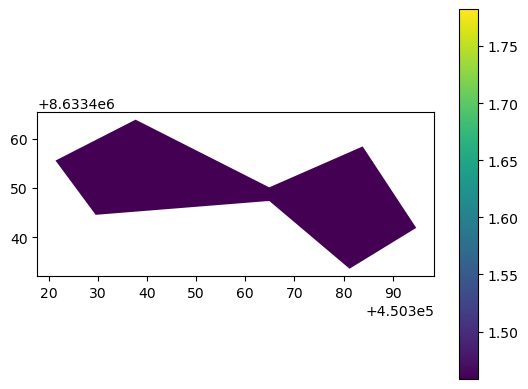

In [59]:
zam_filt.iloc[[2]].plot(column="shape_index", cmap="viridis", legend=True)